## Laboratorio 5 - One vs. All
**Nombre:** Plaza López Cesar Manuel

**Carrera:** Ingeniería de Sistemas

## Preprocesamiento de Datos

In [2]:
import os
import cv2
import numpy as np
import scipy.io

# 1. Rutas y configuración de clases
dataset_dir = 'Rice_Image_Dataset'
classes = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

X_list = []
y_list = []

print("Procesando las 75,000 imágenes...")

# 2. Recorrer las subcarpetas y convertir las fotos a matriz
for label_idx, class_name in enumerate(classes):
    class_folder = os.path.join(dataset_dir, class_name)
    if os.path.exists(class_folder):
        for img_name in os.listdir(class_folder):
            if img_name.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(class_folder, img_name)
                
                # Leer en escala de grises y redimensionar a 28x28 (784 píxeles)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img_resized = cv2.resize(img, (28, 28))
                    X_list.append(img_resized.flatten()) # Vector de 784 características
                    y_list.append(label_idx)

# 3. Formatear a matrices de NumPy
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int64).reshape(-1, 1)

print(f"Dimensiones de X: {X.shape}") # Debería ser (75000, 784)
print(f"Dimensiones de y: {y.shape}") # Debería ser (75000, 1)

# 4. Guardar en formato .mat comprimido
output_filename = 'dataset_laboratorio.mat'
scipy.io.savemat(output_filename, {'X': X, 'y': y}, do_compression=True)

print(f"¡Éxito! Archivo '{output_filename}' creado y listo para enviar.")

Procesando las 75,000 imágenes...
Dimensiones de X: (75000, 784)
Dimensiones de y: (75000, 1)
¡Éxito! Archivo 'dataset_laboratorio.mat' creado y listo para enviar.


## 1.- Librerías

In [4]:
# Importación de librerías
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import optimize
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

%matplotlib inline

# 1. Carga de datos
data = loadmat('dataset_laboratorio.mat')
X_raw = data['X']
y_raw = data['y'].ravel()

# 2. Preprocesamiento y balanceo usando Pandas
df = pd.DataFrame(X_raw)
df['target'] = y_raw

# Muestreo balanceado de 15,000 imágenes por cada clase usando concat
df_list = []
for c in range(5):
    sub_df = df[df['target'] == c].sample(n=15000, random_state=42)
    df_list.append(sub_df)

df_balanced = pd.concat(df_list, axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# 3. Extraer X e y del DataFrame balanceado
y_balanced = df_balanced['target'].values
X_balanced = df_balanced.drop(columns=['target']).values

# 4. División del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.20, random_state=42, stratify=y_balanced
)

# 5. Normalización de imágenes a rango [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# 6. Variables para el resto del laboratorio
X = X_train
y = y_train
m = y.size

print(f"Dataset total cargado: {X_raw.shape[0]} muestras")
print(f"Muestras de Entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras de Prueba (20%): {X_test.shape[0]}")

Dataset total cargado: 75000 muestras
Muestras de Entrenamiento (80%): 60000
Muestras de Prueba (20%): 15000


In [12]:
# Ingresar imágenes de granos de arroz de 28x28
input_layer_size = 784

# 5 etiquetas (clases de 0 a 4: Arborio, Basmati, Ipsala, Jasmine, Karacadag)
num_labels = 5

# datos de entrenamiento almacenados en los arreglos X, y
data = loadmat('dataset_laboratorio.mat')

X, y = data['X'], data['y'].ravel()

# Nota: No necesitamos la línea "y[y == 10] = 0" porque nuestras etiquetas
# ya están correctamente indexadas en Python desde 0 hasta 4.

m = y.size

# Verificación de parámetros básicos
print(f"Número de características (input_layer_size): {input_layer_size}")
print(f"Número de clases (num_labels): {num_labels}")
print(f"Número total de muestras (m): {m}")

Número de características (input_layer_size): 784
Número de clases (num_labels): 5
Número total de muestras (m): 75000


### 1.2 Visualización de los datos

Se comenzará visualizando un subconjunto del conjunto de entrenamiento. Se selecciona al azar, 100 filas de `X` y pasa esas filas a la función` displayData`. 

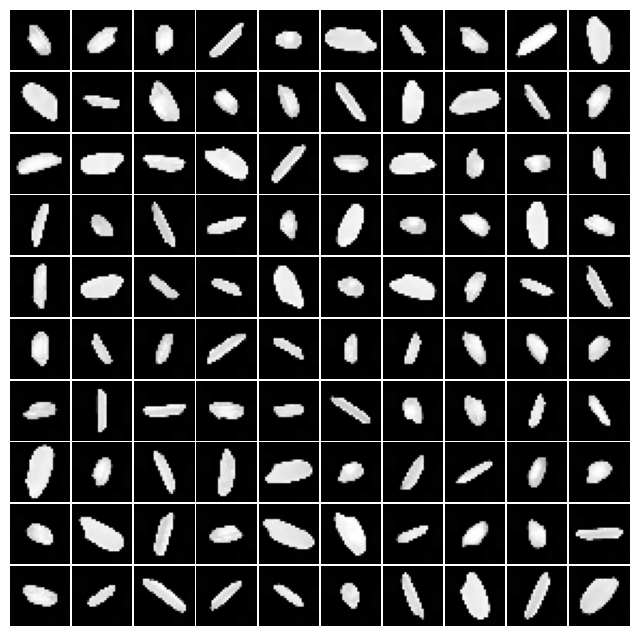

In [18]:
# Definición de la función displayData para imágenes normalizadas [0, 1]
def displayData(X, example_width=None):
    if X.ndim == 1:
        X = X[np.newaxis, :]

    if example_width is None:
        example_width = int(np.round(np.sqrt(X.shape[1])))

    m, n = X.shape
    example_height = int(n / example_width)

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=(8, 8))
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = np.array(ax_array).reshape(-1)

    for i in range(m):
        # Desescalar temporalmente a 255 si es necesario para graficar
        curr_ex = X[i, :].reshape(example_height, example_width)
        ax_array[i].imshow(curr_ex, cmap='gray')
        ax_array[i].set_axis_off()

    # Ocultar ejes sobrantes
    for j in range(m, len(ax_array)):
        ax_array[j].set_visible(False)

    plt.show()

# Probar visualización con 100 muestras aleatorias del conjunto de entrenamiento
m_train = X_train.shape[0]
rand_indices = np.random.choice(m_train, 100, replace=False)
sel = X_train[rand_indices, :]

displayData(sel)

### 1.3 Vectorización de regresión logística

Se utilizará múltiples modelos de regresión logística uno contra todos para construir un clasificador de clases múltiples. Dado que hay 10 clases, deberá entrenar 10 clasificadores de regresión logística separados. Para que esta capacitación sea eficiente, es importante asegurarse de que el código esté bien vectorizado.

En esta sección, se implementará una versión vectorizada de regresión logística que no emplea ningún bucle "for".

Para probar la regresión logística vectorizada, se usara datos personalizados como se definen a continuación.

In [19]:
# valores de prueba para los parámetros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F')/10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

### 1.3.1 Función de costo y gradiente vectorizados

In [10]:
def sigmoid(z):
    """
    Calcula la sigmoide de z de forma numéricamente estable.
    """
    # Evita el desbordamiento (overflow) recortando los valores de z entre -500 y 500
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

In [11]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo con respecto a los parámetros.
    """
    # Inicializa algunos valores útiles
    m = y.size

    # Convierte las etiquetas a valores enteros si son booleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    # Hipótesis
    h = sigmoid(X.dot(theta))

    # Parámetro de regularización (sin regularizar theta[0])
    temp = theta.copy()
    temp[0] = 0

    # Pequeña tolerancia para evitar log(0)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)

    # Cálculo del costo regularizado
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # Cálculo del gradiente regularizado
    grad = (1 / m) * (h - y).dot(X) + (lambda_ / m) * temp

    return J, grad

#### 1.3.3 Vectorización regularizada de la regresión logística


In [20]:
J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo         : {:.6f}'.format(J))
print('Costo esperadot: 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]');

Costo         : 2.534819
Costo esperadot: 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


### 1.4 Clasificacion One-vs-all


In [21]:
# Escalar los píxeles de [0, 255] a [0, 1] para estabilidad matemática
if X.max() > 1.0:
    X = X / 255.0

print(f"Rango de valores en X: mín={X.min()}, máx={X.max()}")

Rango de valores en X: mín=0.0, máx=1.0


In [22]:
### 1.4 Clasificación One-vs-All con Historial de Costo

def oneVsAll(X, y, num_labels, lambda_, maxiter=100):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X_bias = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Diccionario para almacenar la evolución del costo por clase
    historial_costos = {}

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        cost_history = []

        # Callback que guarda el costo en cada iteración de scipy
        def callback(theta):
            costo, _ = lrCostFunction(theta, X_bias, (y == c), lambda_)
            cost_history.append(costo)

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            args=(X_bias, (y == c), lambda_),
            method='CG',
            jac=True,
            callback=callback,
            options={'maxiter': maxiter}
        )
        
        all_theta[c] = res.x
        historial_costos[c] = cost_history

    return all_theta, historial_costos

In [23]:
# Definición de parámetros e inicio del entrenamiento
num_labels = 5  # 5 variedades de arroz
lambda_ = 0.001

# Entrenamiento únicamente con el conjunto de entrenamiento (80%)
all_theta, historial_costos = oneVsAll(X_train, y_train, num_labels, lambda_, maxiter=100)

print("--- ENTRENAMIENTO COMPLETADO ---")
print(f"Dimensiones de all_theta: {all_theta.shape}")

--- ENTRENAMIENTO COMPLETADO ---
Dimensiones de all_theta: (5, 785)


In [24]:
# Imprimir dimensiones y primeros pesos
print(f"Dimensiones de all_theta: {all_theta.shape}")
print("Primeros 10 pesos de la primera clase (Arborio):")
print(all_theta[0][:10])

Dimensiones de all_theta: (5, 785)
Primeros 10 pesos de la primera clase (Arborio):
[-12.58222595   0.           0.           0.           0.
   0.           0.           0.           0.           0.        ]


#### 1.4.1 Prediccion One-vs-all


In [28]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)
    return p

# Precisión en Entrenamiento (80%) y Prueba (20%)
pred_train = predictOneVsAll(all_theta, X_train)
precision_train = np.mean(pred_train == y_train) * 100

pred_test = predictOneVsAll(all_theta, X_test)
precision_test = np.mean(pred_test == y_test) * 100

print(f"Precisión en Entrenamiento (80%): {precision_train:.2f}%")
print(f"Precisión en PRUEBA (20%):        {precision_test:.2f}%")

Precisión en Entrenamiento (80%): 95.38%
Precisión en PRUEBA (20%):        95.05%


Una vez que haya terminado, se llama a la función `predictOneVsAll` usando el valor aprendido de $\theta$. 

(75000, 784)
Precision del conjuto de entrenamiento: 95.31%
(100, 784)
(100, 785)

--- COMPARACIÓN (Predicción vs Real) ---
Predicciones (p): [0 3 0 4 0 0 0 1 4 0 3 1 1 0 3 2 0 0 1 3 2 2 0 2 0 2 1 3 2 3 1 3 1 0 1 2 1
 2 1 4 3 0 3 3 2 0 3 4 2 4 1 4 3 3 2 2 1 1 0 4 2 4 3 0 2 0 0 3 0 4 0 4 3 3
 2 0 1 3 2 3 2 0 1 4 4 2 0 4 2 0 1 2 0 0 1 2 3 4 4 4]
Etiquetas Reales: [0 3 0 4 0 0 0 1 4 0 3 3 1 0 3 2 0 0 1 3 2 2 0 2 0 2 1 3 2 3 1 3 1 0 1 2 1
 2 1 4 3 0 3 3 2 0 3 4 2 4 1 4 3 3 2 2 1 1 0 4 2 4 3 0 2 0 0 3 0 4 0 4 3 3
 2 0 3 3 2 3 2 0 1 4 4 2 0 4 2 0 3 2 0 0 1 2 3 4 4 4]


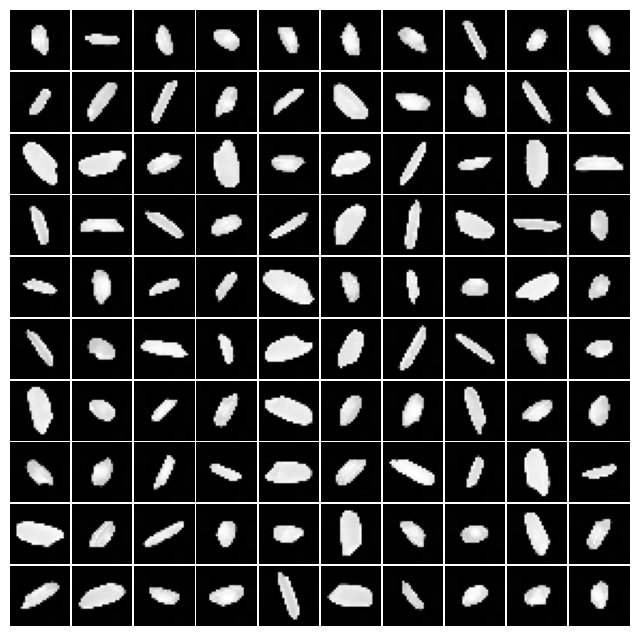

In [29]:
print(X.shape)
pred = predictOneVsAll(all_theta, X)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred == y) * 100))

# Selecciona aleatoriamente 100 puntos de datos para mostrar
rand_indices = np.random.choice(m, 100, replace=False)
XPrueba = X[rand_indices, :].copy()
XPruebaV = XPrueba.copy()

print(XPrueba.shape)

# Agregar término de intercepción (bias) para la prueba
XPrueba = np.concatenate([np.ones((100, 1)), XPrueba], axis=1)
print(XPrueba.shape)

# Obtener las clases predichas para la muestra
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print("\n--- COMPARACIÓN (Predicción vs Real) ---")
print("Predicciones (p):", p)
print("Etiquetas Reales:", y[rand_indices])

# Desplegar la cuadrícula de 100 imágenes probadas
displayData(XPruebaV)

Para validar la efectividad de los parámetros $\theta$ obtenidos, realizamos la predicción sobre el 20% de los datos reservados exclusivamente para prueba (X_test). Comparamos las clases predichas por nuestra función predictOneVsAll contra las etiquetas reales y_test tanto de forma cuantitativa (precisión global) como de forma cualitativa (muestreo aleatorio de 100 imágenes).

## Gráfica de Costo (Evolución de $J(\theta)$ por clase)

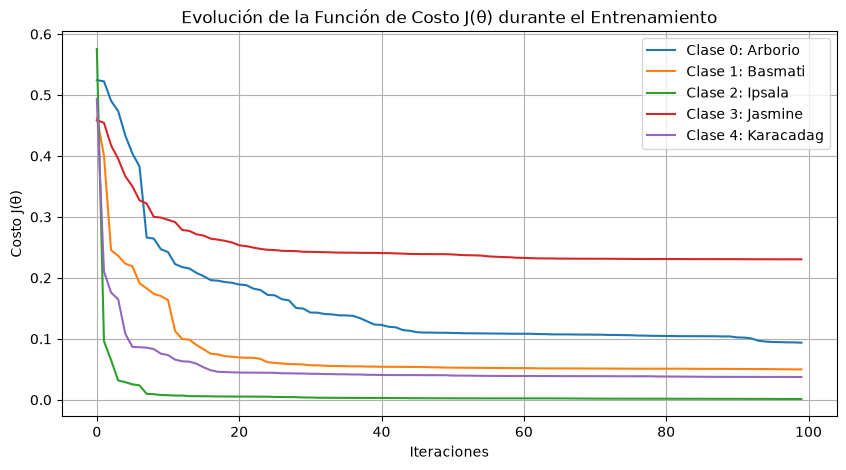

In [30]:
# Gráfica de convergencia de la función de costo por clase
clases_nombres = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']

plt.figure(figsize=(10, 5))
for c in range(num_labels):
    plt.plot(historial_costos[c], label=f'Clase {c}: {clases_nombres[c]}')

plt.title('Evolución de la Función de Costo J(θ) durante el Entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Costo J(θ)')
plt.legend()
plt.grid(True)
plt.show()


--- COMPARACIÓN SOBRE DATOS DE PRUEBA (Predicción vs Real) ---
Predicciones (p): [2 0 0 0 4 3 0 1 2 2 3 1 2 0 4 3 4 3 2 4 0 0 0 2 1 2 1 2 0 3 0 0 2 0 3 0 0
 0 1 2 1 0 1 1 1 3 0 1 0 0 0 3 2 3 0 3 2 1 4 2 2 3 0 1 1 1 4 0 0 1 0 4 1 2
 1 1 2 2 3 1 2 2 2 0 2 3 2 0 3 1 0 1 1 2 3 1 0 0 3 3]
Etiquetas Reales: [2 0 0 0 4 3 0 3 2 2 3 1 2 0 4 0 4 3 2 4 0 0 0 2 1 2 1 2 0 3 3 0 2 0 3 0 0
 0 1 2 1 0 1 3 1 3 0 1 0 0 0 3 2 3 0 3 2 1 4 2 2 3 0 1 1 1 4 0 0 1 0 4 1 2
 1 1 2 2 3 1 2 2 2 0 2 3 2 0 3 3 0 1 1 2 3 3 0 0 3 3]


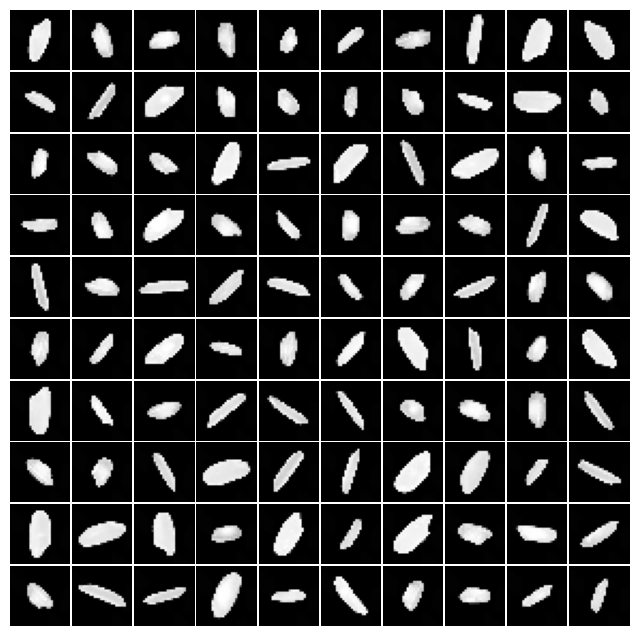

In [31]:
# Probar 100 muestras del conjunto de PRUEBA (datos desasociados)
m_test = X_test.shape[0]
rand_indices = np.random.choice(m_test, 100, replace=False)

XPrueba = X_test[rand_indices, :].copy()
XPruebaV = XPrueba.copy()

XPrueba = np.concatenate([np.ones((100, 1)), XPrueba], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print("\n--- COMPARACIÓN SOBRE DATOS DE PRUEBA (Predicción vs Real) ---")
print("Predicciones (p):", p)
print("Etiquetas Reales:", y_test[rand_indices])

displayData(XPruebaV)